In [1]:
import gym
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import rl_utils


class PolicyNet(torch.nn.Module):# state -> action
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)


class ValueNet(torch.nn.Module): #state -> value in R
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class PPO:
    ''' PPO算法,采用截断方式 '''
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, epochs, eps, gamma, device):
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)
        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs = epochs  # 一条序列的数据用于训练轮数
        self.eps = eps  # PPO中截断范围的参数
        self.device = device

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)
        td_delta = td_target - self.critic(states)
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda, td_delta.cpu()).to(self.device)
        old_log_probs = torch.log(self.actor(states).gather(1, actions)).detach()

        for _ in range(self.epochs):
            log_probs = torch.log(self.actor(states).gather(1, actions))
            ratio = torch.exp(log_probs - old_log_probs)
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1 - self.eps, 1 + self.eps) * advantage  # 截断
            actor_loss = torch.mean(-torch.min(surr1, surr2))  # PPO损失函数
            critic_loss = torch.mean(F.mse_loss(self.critic(states), td_target.detach()))
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            actor_loss.backward()
            critic_loss.backward()
            self.actor_optimizer.step()
            self.critic_optimizer.step()


actor_lr = 1e-3
critic_lr = 1e-2
num_episodes = 250
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
epochs = 10
eps = 0.2
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v0'
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
ppo_agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, epochs, eps, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, ppo_agent, num_episodes)

# Iteration 0: 100%|██████████| 25/25 [00:00<00:00, 32.56it/s, episode=20,
# return=40.700]
# Iteration 1: 100%|██████████| 25/25 [00:09<00:00,  2.75it/s, episode=45,
# return=182.800]
# Iteration 2: 100%|██████████| 25/25 [00:11<00:00,  2.27it/s, episode=70,
# return=176.100]
# Iteration 3: 100%|██████████| 25/25 [00:11<00:00,  2.16it/s, episode=95,
# return=194.500]
# Iteration 4: 100%|██████████| 25/25 [00:11<00:00,  2.08it/s, episode=120,
# return=180.600]
# Iteration 5: 100%|██████████| 25/25 [00:12<00:00,  2.03it/s, episode=145,
# return=200.000]
# Iteration 6: 100%|██████████| 25/25 [00:11<00:00,  2.08it/s, episode=170,
# return=185.700]
# Iteration 7: 100%|██████████| 25/25 [00:11<00:00,  2.14it/s, episode=195,
# return=200.000]
# Iteration 8: 100%|██████████| 25/25 [00:12<00:00,  2.05it/s, episode=220,
# return=200.000]
# Iteration 9: 100%|██████████| 25/25 [00:11<00:00,  2.27it/s, episode=245,
# return=196.900]


/home/multiagent/anaconda3/envs/HonRL/lib/python3.8/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.


Iteration 0:   0%|          | 0/25 [00:00<?, ?it/s]/tmp/ipykernel_4677/2900204591.py:48: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 25/25 [00:02<00:00,  9.45it/s, episode=245, return=195.900]


## We got an export agent(trained from ppo)

In [2]:
def sample_expert_data(n_episode): # total trail num
    states = []
    actions = []
    for episode in range(n_episode):
        state = env.reset()
        done = False
        while not done:
            action = ppo_agent.take_action(state)
            states.append(state)
            actions.append(action)
            next_state, reward, done, _ = env.step(action)
            state = next_state
    return np.array(states), np.array(actions)


env.seed(0)
torch.manual_seed(0)
random.seed(0)
n_episode = 1# just one trail
expert_s, expert_a = sample_expert_data(n_episode)

n_samples = 30  #  sample 30 pairs in this trail提高到100后 bc算法有明显提升
random_index = random.sample(range(expert_s.shape[0]), n_samples)
#make it random
expert_s = expert_s[random_index]
expert_a = expert_a[random_index]

In [3]:
class BehaviorClone:
    def __init__(self, state_dim, hidden_dim, action_dim, lr):
        self.policy = PolicyNet(state_dim, hidden_dim, action_dim).to(device)# state to action
        self.optimizer = torch.optim.Adam(self.policy.parameters(), lr=lr)

    def learn(self, states, actions):
        states = torch.tensor(states, dtype=torch.float).to(device)
        actions = torch.tensor(actions).view(-1, 1).to(device)
        log_probs = torch.log(self.policy(states).gather(1, actions))# get action probability in this policy
        bc_loss = torch.mean(-log_probs)  # 最大似然估计logistic

        self.optimizer.zero_grad()
        bc_loss.backward()
        self.optimizer.step()

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(device)
        probs = self.policy(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()


def test_agent(agent, env, n_episode):
    return_list = []
    for episode in range(n_episode):
        episode_return = 0
        state = env.reset()
        done = False
        while not done:
            action = agent.take_action(state)
            next_state, reward, done, _ = env.step(action)
            state = next_state
            episode_return += reward
        return_list.append(episode_return)
    return np.mean(return_list)


env.seed(0)
torch.manual_seed(0)
np.random.seed(0)

lr = 1e-3
bc_agent = BehaviorClone(state_dim, hidden_dim, action_dim, lr)
n_iterations = 1000
batch_size = 64
test_returns = []

with tqdm(total=n_iterations, desc="进度条") as pbar:
    for i in range(n_iterations):
        sample_indices = np.random.randint(low=0,
                                           high=expert_s.shape[0],
                                           size=batch_size)
        bc_agent.learn(expert_s[sample_indices], expert_a[sample_indices])
        current_return = test_agent(bc_agent, env, 5)
        test_returns.append(current_return)
        if (i + 1) % 10 == 0:
            pbar.set_postfix({'return': '%.3f' % np.mean(test_returns[-10:])})
        pbar.update(1)

# 进度条: 100%|██████████| 1000/1000 [00:50<00:00, 19.82it/s, return=42.000]

进度条:   0%|          | 0/1000 [00:00<?, ?it/s]

进度条: 100%|██████████| 1000/1000 [00:52<00:00, 19.20it/s, return=34.100]


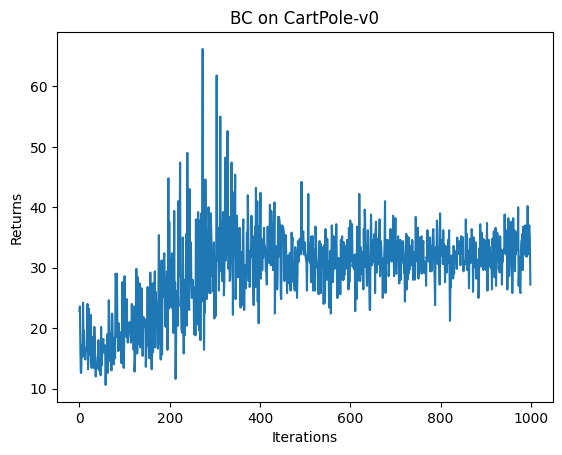

In [4]:
iteration_list = list(range(len(test_returns)))
plt.plot(iteration_list, test_returns)
plt.xlabel('Iterations')
plt.ylabel('Returns')
plt.title('BC on {}'.format(env_name))
plt.show()

In [5]:
expert_a.shape
print(expert_a)
expert_actions = F.one_hot(torch.tensor(expert_a), num_classes=2).float()
print(expert_actions)

[0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]
tensor([[1., 0.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [0., 1.]])


In [6]:
F.one_hot(torch.arange(0, 5), num_classes=5)

tensor([[1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1]])

https://www.geeksforgeeks.org/ml-one-hot-encoding-of-datasets-in-python/

It allows the use of categorical variables in models that require numerical input.

It can improve model performance by providing more information to the model about the categorical variable.

It can help to avoid the problem of ordinality, which can occur when a categorical variable has a natural ordering (e.g. “small”, “medium”, “large”).

In [7]:
class ValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super().__init__()
        self.Linear1 = torch.nn.Linear(state_dim, hidden_dim)
        self.Linear2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.Linear1(x))
        return self.Linear2(x)

In [8]:
class ActorCritic:
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr, gamma, device):
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)

        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr = actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr = critic_lr)

        self.gamma = gamma
        self.device = device
    
    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()
    
    def update(self, transition_dict):
        # one trial

        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)
        
        #critic learns value: funcion state -> R
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)
        td_delta = td_target - self.critic(states) # td-error


        
        # every state and action in this trial
        # using td error to train critic-loss <states and next-state given by trail sampling by ACTOR network
        critic_loss = torch.sum(F.mse_loss(self.critic(states), td_target.detach()))# should be sum according to the algorithm given in the book
        
        # ACTOR LEARNS policy
        # the critic network critic actor through td_error
        log_probs = torch.log(self.actor(states).gather(1, actions))
        actor_loss = torch.sum(-log_probs * td_delta.detach())# the Expectation gradient J(theta)
        #should be sum instead of mean

        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        actor_loss.backward()
        critic_loss.backward()
        self.actor_optimizer.step()
        self.critic_optimizer.step()

        

In [9]:
class VAnet(torch.nn.Module):
    ''' 只有一层隐藏层的A网络和V网络 '''
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(VAnet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)  # 共享网络部分
        self.fc_A = torch.nn.Linear(hidden_dim, action_dim)
        self.fc_V = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        A = self.fc_A(F.relu(self.fc1(x)))
        V = self.fc_V(F.relu(self.fc1(x)))
        Q = V + A - A.mean(1).view(-1, 1)  # Q值由V值和A值计算得到
        return Q


class DQN:
    ''' DQN算法,包括Double DQN和Dueling DQN '''
    def __init__(self,
                 state_dim,
                 hidden_dim,
                 action_dim,
                 learning_rate,
                 gamma,
                 epsilon,
                 target_update,
                 device,
                 dqn_type='VanillaDQN'):
        self.action_dim = action_dim
        if dqn_type == 'DuelingDQN':  # Dueling DQN采取不一样的网络框架
            self.q_net = VAnet(state_dim, hidden_dim,
                               self.action_dim).to(device)
            self.target_q_net = VAnet(state_dim, hidden_dim,
                                      self.action_dim).to(device)
        else:
            self.q_net = Qnet(state_dim, hidden_dim,
                              self.action_dim).to(device)
            self.target_q_net = Qnet(state_dim, hidden_dim,
                                     self.action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.q_net.parameters(),
                                          lr=learning_rate)
        self.gamma = gamma
        self.epsilon = epsilon
        self.target_update = target_update
        self.count = 0
        self.dqn_type = dqn_type
        self.device = device

    def take_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state], dtype=torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
        return action

    def max_q_value(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        return self.q_net(state).max().item()

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(
            self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)

        q_values = self.q_net(states).gather(1, actions)
        if self.dqn_type == 'DoubleDQN':
            max_action = self.q_net(next_states).max(1)[1].view(-1, 1)
            max_next_q_values = self.target_q_net(next_states).gather(
                1, max_action)
        else:
            max_next_q_values = self.target_q_net(next_states).max(1)[0].view(
                -1, 1)
        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets))
        self.optimizer.zero_grad()
        dqn_loss.backward()
        self.optimizer.step()

        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())
        self.count += 1


In [10]:
# class PolicyNet(torch.nn.Module):
#     def __init__(self, state_dim, hidden_dim, action_dim):
#         super(PolicyNet, self).__init__()
#         self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
#         self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         return F.softmax(self.fc2(x), dim=1)


# class ValueNet(torch.nn.Module):
#     def __init__(self, state_dim, hidden_dim):
#         super(ValueNet, self).__init__()
#         self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
#         self.fc2 = torch.nn.Linear(hidden_dim, 1)

#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         return self.fc2(x)

# def self_kl_div(P, Q):
#     return (P * (P / Q).log()).sum()


In [11]:
class PPOPenality:
    ''' PPO-penalty'''
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, kl_constraint, epochs_m, epochs_b, beta, gamma, device):
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)
        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs_m =  epochs_m  # 一条序列的数据用来训练轮数 one trail
        self.epochs_b = epochs_b
        self.beta = beta  # 
        self.kl_constraint = kl_constraint
        self.device = device


    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()
    
    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)
        td_target = rewards + self.gamma * self.critic(next_states) * (1 -dones)
        td_delta = td_target - self.critic(states)
        # target critic net---in some way
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda,td_delta.cpu()).to(self.device)
        # same trail given same approximate advantage
        old_log_probs = torch.log(self.actor(states).gather(1, actions)).detach() #theta_k
        # target actor net --- in some way                     

        with torch.no_grad():
            old_action_dists = torch.distributions.Categorical(self.actor(states))
        #old_action_dist = torch.tensor(self.actor(states)).detach()
            
        for _ in range(self.epochs_m):# one step may not reach the optimal point
            log_probs = torch.log(self.actor(states).gather(1, actions))
            ratio = torch.exp(log_probs - old_log_probs)
            surr1 = ratio * advantage
           
            curr_action_dists = torch.distributions.Categorical(self.actor(states))
            # curr_action_dist = torch.tensor(self.actor(states))
            curr_kl_div = torch.distributions.kl.kl_divergence(old_action_dists, curr_action_dists)
            #= self_kl_div(curr_action_dist, old_action_dist)
            actor_loss = -torch.mean(surr1 - self.beta * curr_kl_div)   # kl损失函数,注意这里有minus


            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()
                
        
        for _ in range(self.epochs_b):
            critic_loss = torch.mean( F.mse_loss(self.critic(states), td_target.detach()))# td_target using "target net"
            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            self.critic_optimizer.step()

        new_action_dists = torch.distributions.Categorical(self.actor(states))
        kl_div = torch.mean(torch.distributions.kl.kl_divergence(old_action_dists, new_action_dists))
        if kl_div < self.kl_constraint / 1.5:
            self.beta /= 2
        if kl_div > 1.5 * self.kl_constraint:
            self.beta *= 2

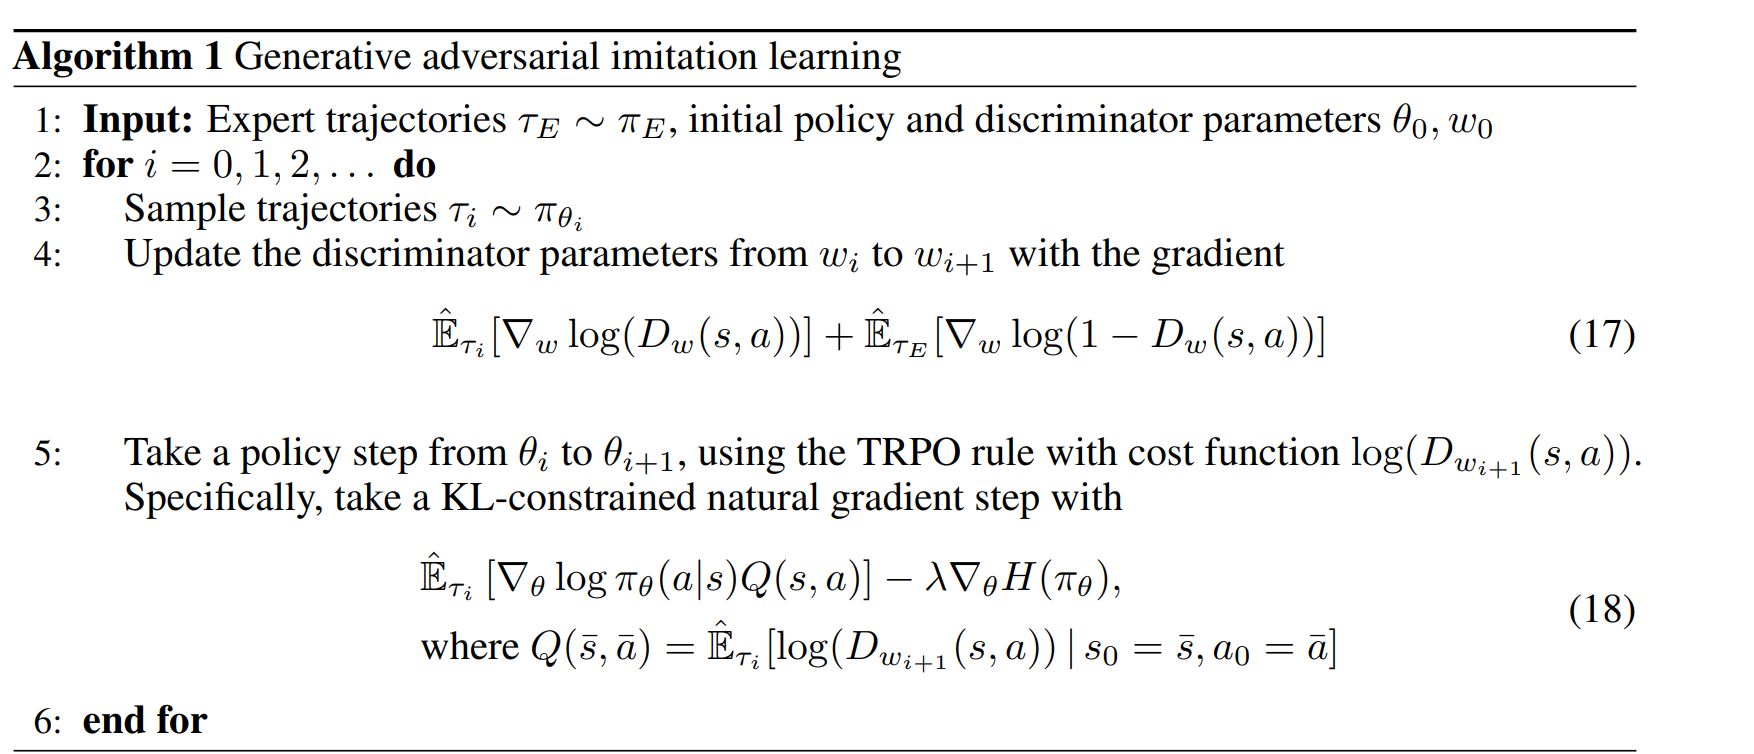

In [12]:
class Discriminator(nn.Module): # state dim +action dim -> [0-1]
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, a):
        cat = torch.cat([x, a], dim=1)
        x = F.relu(self.fc1(cat))
        return torch.sigmoid(self.fc2(x))# turn it into 0-1

In [13]:
class GAIL:
    def __init__(self, agent, state_dim, action_dim, hidden_dim, lr_d):
        self.discriminator = Discriminator(state_dim, hidden_dim, action_dim).to(device)
        self.discriminator_optimizer = torch.optim.Adam(self.discriminator.parameters(), lr=lr_d)
        self.agent = agent

    def learn(self, expert_s, expert_a, agent_s, agent_a, next_s, dones):
        expert_states = torch.tensor(expert_s, dtype=torch.float).to(device)
        expert_actions = torch.tensor(expert_a).to(device)
        agent_states = torch.tensor(agent_s, dtype=torch.float).to(device)
        agent_actions = torch.tensor(agent_a).to(device) 
        # one hot encoding, line up the dimension
        expert_actions = F.one_hot(expert_actions, num_classes=2).float() #action space[0.1]
        agent_actions = F.one_hot(agent_actions, num_classes=2).float()
       

        expert_prob = self.discriminator(expert_states, expert_actions)
        agent_prob = self.discriminator(agent_states, agent_actions)
        loss = nn.BCELoss() # Binary Cross Entropy 
        discriminator_loss = loss(agent_prob, torch.ones_like(agent_prob)) + loss(expert_prob, torch.zeros_like(expert_prob))
        self.discriminator_optimizer.zero_grad()
        discriminator_loss.backward()
        self.discriminator_optimizer.step()

        rewards = -torch.log(agent_prob).detach().cpu().numpy()
        transition_dict = {
            'states': agent_s,
            'actions': agent_a,
            'rewards': rewards,
            'next_states': next_s,
            'dones': dones
        }
        self.agent.update(transition_dict)


env.seed(0)
torch.manual_seed(0)
lr_d = 1e-3
epsilon = 0.01
target_update = 50
kl_constraint = 0.001
epochs_m = 10
epochs_b = 20
beta = 1
agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, epochs, eps, gamma, device)
#agent = ActorCritic(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, gamma, device)
#agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon, target_update, device, 'DuelingDQN')
agent = PPOPenality(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, kl_constraint, epochs_m, epochs_b, beta, gamma, device)
gail = GAIL(agent, state_dim, action_dim, hidden_dim, lr_d)
n_episode = 500
return_list = []

with tqdm(total=n_episode, desc="进度条") as pbar:
    for i in range(n_episode):
        episode_return = 0
        state = env.reset()
        done = False
        state_list = []
        action_list = []
        next_state_list = []
        done_list = []
        while not done:
            action = agent.take_action(state)
            next_state, reward, done, _ = env.step(action)
            state_list.append(state)
            action_list.append(action)
            next_state_list.append(next_state)
            done_list.append(done)
            state = next_state
            episode_return += reward
        return_list.append(episode_return)
        gail.learn(expert_s, expert_a, state_list, action_list, next_state_list, done_list)
        if (i + 1) % 10 == 0:
            pbar.set_postfix({'return': '%.3f' % np.mean(return_list[-10:])})
        pbar.update(1)

# 进度条: 100%|██████████| 500/500 [04:08<00:00,  2.01it/s, return=200.000]

进度条:   0%|          | 0/500 [00:00<?, ?it/s]

进度条: 100%|██████████| 500/500 [00:57<00:00,  8.64it/s, return=196.200]


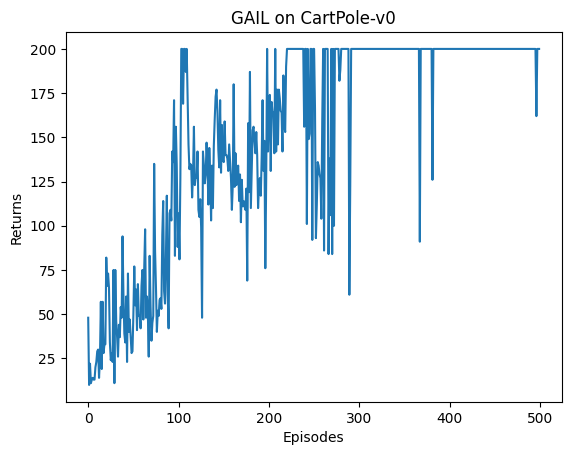

In [15]:
iteration_list = list(range(len(return_list)))
plt.plot(iteration_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('GAIL on {}'.format(env_name))
plt.show()